In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import glob
from pathlib import Path



In [5]:
METHODS = ['pca', 'I']
MODELS = ['wavlm', 'whisper', 'opt-125m', 'opt-1.3b', 'pythia-160m']

In [6]:
HOME = Path.home()
str(HOME)

'/home/echeng'

In [7]:
fields = ['corr', 'alphas']

In [46]:
# LOAD IN RESULTS
RESULTS = []

for model in MODELS:
    for m in METHODS:
        files = glob.glob(f'{str(HOME)}/encoding-models/results/{model}/*{m}*ridge.json')
        for file in tqdm(files):
            layer_num = int(file.split('layer_')[1].split('_')[0])

            try:
                with open(file, 'r') as f:
                    result = json.load(f)
            except:
                continue

            summary = []
            results_names = []

            for field in fields:
                if type(result[field]) == list:
                    if field == 'alphas': continue
                    summary.append(np.mean(result[field]))
                    summary.append(np.std(result[field]))
                    summary.append(np.min(result[field]))
                    summary.append(np.max(result[field]))
                    summary.append(len(result[field]))
                    results_names.extend([field + tag for tag in ['_mean', '_std', '_min', '_max', '_N']])
                else:
                    summary.append(result[field])
                    results_names.append(field)
    
            if m != 'I':
                summary.append(result['params']['n_evecs'])
            else:
                summary.append(np.infty)

            # metadata
            summary.append(m)
            summary.append(layer_num)
            summary.append(model)
            RESULTS.append(summary)

result_df = pd.DataFrame(RESULTS, columns=results_names + ['n_evecs', 'method', 'layer', 'model'])

100%|██████████| 13/13 [00:24<00:00,  1.86s/it]


ValueError: 9 columns passed, passed data had 10 columns

In [47]:
for i in range(len(RESULTS)):
    if len(RESULTS[i]) == 10:
        pass
    else:
        RESULTS[i] = RESULTS[i][:5] + ['None'] + RESULTS[i][5:]

In [48]:
results_names

['corr_mean', 'corr_std', 'corr_min', 'corr_max', 'corr_N']

In [30]:
RESULTS[1]

[0.08133380300777884,
 0.1042329210721221,
 -0.17639713917977431,
 0.5967284533408777,
 95556,
 316.2277660168379,
 400.0,
 'pca',
 18,
 'wavlm']

In [49]:
result_df = pd.DataFrame(RESULTS, columns=results_names + ['best_alpha', 'n_evecs', 'method', 'layer', 'model'])

In [50]:
result_df.columns

Index(['corr_mean', 'corr_std', 'corr_min', 'corr_max', 'corr_N', 'best_alpha',
       'n_evecs', 'method', 'layer', 'model'],
      dtype='object')

In [51]:
plot_df = result_df.groupby(['model', 'method', 'layer']).agg({'corr_mean': 'max'}).reset_index()
plot_df

,model,method,layer,corr_mean
0,opt-1.3b,I,0,0.090981
1,opt-1.3b,I,1,0.105112
2,opt-1.3b,I,2,0.109663
3,opt-1.3b,I,3,0.113750
4,opt-1.3b,I,4,0.114837
...,...,...,...,...
170,whisper,pca,16,0.094413
171,whisper,pca,18,0.096547
172,whisper,pca,20,0.102370
173,whisper,pca,22,0.114209


In [52]:
plot_df.to_csv('temp_all_results.csv')

## Best (out of PCA grid) and baseline

/home/echeng/miniconda3/envs/compsem/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/echeng/miniconda3/envs/compsem/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


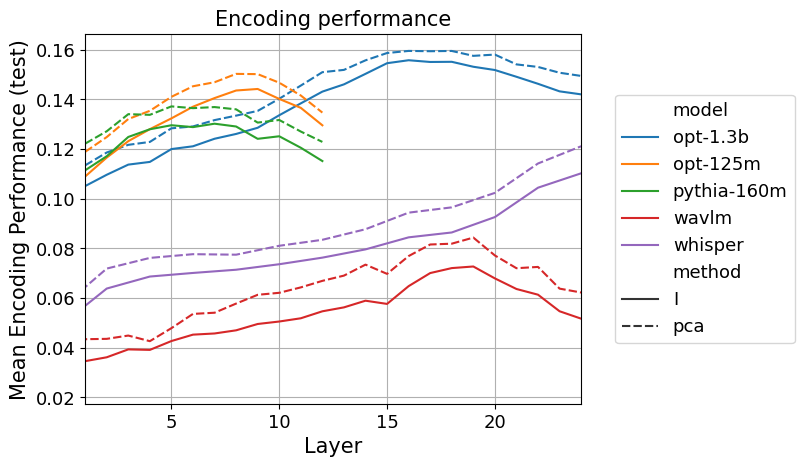

In [54]:
plot_df = result_df.groupby(['model', 'method', 'layer']).agg({'corr_mean': 'max'}).reset_index()
sns.lineplot(data=plot_df, x='layer', y='corr_mean', hue='model', style='method')
plt.ylabel('Mean Encoding Performance (test)', fontsize=15)
plt.xlabel('Layer', fontsize=15)
plt.title('Encoding performance', fontsize=15)
plt.xlim([1, 24])
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.legend(fontsize=13, bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.grid()

In [27]:
LAYER_NUM = 18
MODEL = 'wavlm'
layer_df = result_df[(result_df['layer'] == LAYER_NUM) & (result_df['model'] == MODEL)]
layer_df = layer_df.loc[
    layer_df.groupby(['n_evecs', 'model', 'method'])['corr_mean'].idxmax()
].reset_index(drop=True)
layer_df

,corr_mean,corr_std,corr_min,corr_max,corr_N,alphas,n_evecs,method,layer,model
0,0.079318,0.100027,-0.161961,0.555612,95556,316.227766,50.0,pca,18,wavlm
1,0.081693,0.102413,-0.187897,0.588350,95556,316.227766,100.0,pca,18,wavlm
2,0.081922,0.103725,-0.179463,0.597617,95556,316.227766,200.0,pca,18,wavlm
3,0.081645,0.104161,-0.176470,0.597033,95556,316.227766,300.0,pca,18,wavlm
4,0.081334,0.104233,-0.176397,0.596728,95556,316.227766,400.0,pca,18,wavlm
5,0.080381,0.103962,-0.157261,0.609581,95556,316.227766,1000.0,pca,18,wavlm
6,0.079072,0.103844,-0.165747,0.614717,95556,316.227766,2000.0,pca,18,wavlm


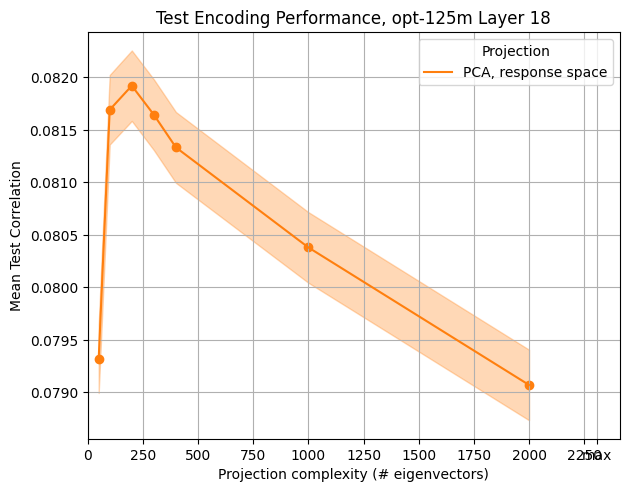

In [28]:
# Sort the dataframe by n_evecs
sorted_df = layer_df.sort_values(by='n_evecs')

# Extract sorted values
x = sorted_df['n_evecs'].values.astype(float)
y = sorted_df['corr_mean'].values.astype(float)
err = sorted_df['corr_std'].values / np.sqrt(sorted_df['corr_N'])  # or std, depending on your column

# Plot line and scatter for PCA
plt.plot(x, y, label='PCA, response space', color='C1')
plt.scatter(x, y, color='C1')

# Shaded error region

plt.fill_between(x, y - err, y + err, alpha=0.3, color='C1')

_, xmax = plt.xlim()

# Add the 'I' point
# plt.scatter([xmax * 1.1], [layer_df[layer_df['method'] == 'I']['corr_mean'].max()], label='None', color='C0')

# Custom x-tick label for max
xticks = plt.xticks()[0]
xticks = np.append(xticks, xmax * 1.1) if xmax * 1.1 not in xticks else xticks
xticks = np.unique(xticks)
xticklabels = [str(int(tick)) if tick != xmax * 1.1 else 'max' for tick in xticks]
plt.xticks(xticks, xticklabels)
plt.xlim([0, xmax * 1.15])
# Labels and legend
plt.xlabel('Projection complexity (# eigenvectors)')
plt.ylabel('Mean Test Correlation')
plt.legend(title='Projection')
plt.grid()
plt.tight_layout()
plt.title(f'Test Encoding Performance, {MODELS[0]} Layer {LAYER_NUM}')
plt.show()
